# Тернарная диаграмма траектории состава Cassandra

Ноутбук читает `.prp` файл Cassandra, берёт `Nmols_1`, `Nmols_2`, `Nmols_3`, переводит их в мольные доли и строит траекторию точек на треугольной диаграмме. Цвет показывает номер MC-шага, стрелки показывают направление движения, а отдельные маркеры показывают начало и конец траектории.

## 1. Настройки

Поменяй `INPUT_PRP` на нужный файл, например `box1.prp` для жидкости или `box2.prp` для пара. Компоненты здесь идут в порядке Cassandra species: вода, этанол, гексан.

In [239]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in (start, *start.parents):
        if (path / "MC" / "data").exists():
            return path
    raise FileNotFoundError("Не нашёл корень проекта с папкой MC/data")
PROJECT_ROOT = find_project_root()
# Входной файл Cassandra .prp
INPUT_PRP = PROJECT_ROOT / "MC" / "azeotrop_data_2" / "azeotrope_gemc_npt_3000_50k.box2.prp"
# Подписи вершин в порядке species 1/2/3
COMPONENTS = ("Water", "Ethanol", "Hexane")

# Доля последних точек, по которым оцениваем, куда сходится траектория.
TAIL_FRACTION = 0.20

# Если нужно убрать начальный переходный участок, поставь, например, 1000.
MIN_STEP = 0

INPUT_PRP

PosixPath('/Users/artemis/Documents/S26S-all/Project-Labs-S26S/MC/azeotrop_data_2/azeotrope_gemc_npt_3000_50k.box2.prp')

## 2. Чтение `.prp` и расчёт мольных долей

In [240]:
PRP_COLUMNS = [
    "step",
    "energy_total",
    "pressure",
    "volume",
    "mass_density",
    "density_1",
    "density_2",
    "density_3",
    "nmols_1",
    "nmols_2",
    "nmols_3",
]


def read_cassandra_prp(path: Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        names=PRP_COLUMNS,
        engine="python",
    )
    df = df.dropna(subset=["step", "nmols_1", "nmols_2", "nmols_3"]).copy()
    df["step"] = df["step"].astype(int)

    nmols_cols = ["nmols_1", "nmols_2", "nmols_3"]
    df["nmols_total"] = df[nmols_cols].sum(axis=1)
    df = df[df["nmols_total"] > 0].copy()

    fraction_cols = ["x1", "x2", "x3"]
    df[fraction_cols] = df[nmols_cols].div(df["nmols_total"], axis=0)
    df = df[df["step"] >= MIN_STEP].reset_index(drop=True)
    return df


df = read_cassandra_prp(INPUT_PRP)
df.head()

,step,energy_total,pressure,volume,mass_density,density_1,density_2,density_3,nmols_1,nmols_2,nmols_3,nmols_total,x1,x2,x3
0,25100,373034.19,1.012123,26811165.0,2.595521,0.000002,0.000005,0.000015,64.0,142.0,397.0,603.0,0.106136,0.235489,0.658375
1,25200,371009.26,1.031176,26811165.0,2.603953,0.000003,0.000005,0.000015,69.0,143.0,397.0,609.0,0.113300,0.234811,0.651888
2,25300,374499.57,1.039171,26811165.0,2.630641,0.000003,0.000005,0.000015,69.0,143.0,402.0,614.0,0.112378,0.232899,0.654723
3,25400,376285.33,1.032776,26811165.0,2.650622,0.000003,0.000005,0.000015,70.0,144.0,405.0,619.0,0.113086,0.232633,0.654281
4,25500,375509.93,0.943765,28538294.0,2.492888,0.000002,0.000005,0.000014,70.0,145.0,405.0,620.0,0.112903,0.233871,0.653226


## 3. Куда сходится состав

`start` — первая точка, `end` — последняя строка файла, `tail_mean` — среднее по последним `TAIL_FRACTION` точек. Для оценки установления равновесия лучше смотреть именно `tail_mean`, а не одну последнюю строку.

In [241]:
def composition_summary(data: pd.DataFrame, tail_fraction: float = 0.20) -> pd.DataFrame:
    fraction_cols = ["x1", "x2", "x3"]
    tail_count = max(1, int(len(data) * tail_fraction))
    tail = data.tail(tail_count)

    rows = []
    for label, row in (
        ("start", data.iloc[0]),
        ("end", data.iloc[-1]),
    ):
        rows.append(
            {
                "point": label,
                "step": int(row["step"]),
                COMPONENTS[0]: row["x1"],
                COMPONENTS[1]: row["x2"],
                COMPONENTS[2]: row["x3"],
                "nmols_total": row["nmols_total"],
            }
        )

    rows.append(
        {
            "point": f"tail_mean_last_{tail_count}",
            "step": f"{int(tail['step'].iloc[0])}..{int(tail['step'].iloc[-1])}",
            COMPONENTS[0]: tail["x1"].mean(),
            COMPONENTS[1]: tail["x2"].mean(),
            COMPONENTS[2]: tail["x3"].mean(),
            "nmols_total": tail["nmols_total"].mean(),
        }
    )

    return pd.DataFrame(rows)


summary = composition_summary(df, TAIL_FRACTION)
summary

,point,step,Water,Ethanol,Hexane,nmols_total
0,start,25100,0.106136,0.235489,0.658375,603.00000
1,end,39500,0.154446,0.255070,0.590484,1282.00000
2,tail_mean_last_29,36700..39500,0.154477,0.251448,0.594075,1232.62069


## 4. Функции для тернарной диаграммы

In [242]:
SQRT3_OVER_2 = np.sqrt(3) / 2


def ternary_to_xy(fractions: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Map water x1 to top, ethanol x2 to left, and hexane x3 to right."""
    fractions = np.asarray(fractions, dtype=float)
    x1 = fractions[..., 0]
    x2 = fractions[..., 1]
    x3 = fractions[..., 2]
    x = x3 + 0.5 * x1
    y = SQRT3_OVER_2 * x1
    return x, y


def draw_ternary_axes(ax, components=COMPONENTS, grid_step=0.1):
    vertices = np.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, SQRT3_OVER_2],
        [0.0, 0.0],
    ])
    ax.plot(vertices[:, 0], vertices[:, 1], color="black", lw=1.5)

    for value in np.arange(grid_step, 1.0, grid_step):
        # constant x1
        p1 = np.array([[value, 1 - value, 0]])
        p2 = np.array([[value, 0, 1 - value]])
        ax.plot(*zip(ternary_to_xy(p1), ternary_to_xy(p2)), color="0.86", lw=0.8)

        # constant x2
        p1 = np.array([[1 - value, value, 0]])
        p2 = np.array([[0, value, 1 - value]])
        ax.plot(*zip(ternary_to_xy(p1), ternary_to_xy(p2)), color="0.86", lw=0.8)

        # constant x3
        p1 = np.array([[1 - value, 0, value]])
        p2 = np.array([[0, 1 - value, value]])
        ax.plot(*zip(ternary_to_xy(p1), ternary_to_xy(p2)), color="0.86", lw=0.8)

    ax.text(-0.04, -0.045, components[1], ha="right", va="top", fontsize=14, weight="bold")
    ax.text(1.04, -0.045, components[2], ha="left", va="top", fontsize=14, weight="bold")
    ax.text(0.5, SQRT3_OVER_2 + 0.045, components[0], ha="center", va="bottom", fontsize=14, weight="bold")

    for value in np.arange(0.2, 1.0, 0.2):
        label = f"{int(value * 100)}%"
        ax.text(value, -0.025, label, ha="center", va="top", fontsize=8, color="0.35")

    ax.set_aspect("equal")
    ax.set_xlim(-0.08, 1.08)
    ax.set_ylim(-0.08, SQRT3_OVER_2 + 0.09)
    ax.axis("off")


def plot_ternary_trajectory(
    data: pd.DataFrame,
    components=COMPONENTS,
    show_points: bool = True,
    show_arrows: bool = True,
    show_colorbar: bool = True,
    guide_smooth_window: int | None = None,
    title: str | None = None,
):
    fractions = data[["x1", "x2", "x3"]].to_numpy()
    x, y = ternary_to_xy(fractions)
    steps = data["step"].to_numpy()

    fig, ax = plt.subplots(figsize=(12, 10.5))
    draw_ternary_axes(ax, components)

    if guide_smooth_window:
        guide = data[["x1", "x2", "x3"]].rolling(
            guide_smooth_window,
            center=True,
            min_periods=1,
        ).mean().to_numpy(copy=True)
        guide[0] = fractions[0]
        guide[-1] = fractions[-1]
        guide_x, guide_y = ternary_to_xy(guide)
        ax.plot(guide_x, guide_y, color="#2f5d8a", lw=2.4, alpha=0.9, zorder=3)
    else:
        ax.plot(x, y, color="0.25", lw=1.0, alpha=0.35, zorder=2)

    scatter = None
    if show_points:
        scatter = ax.scatter(x, y, c=steps, cmap="viridis", s=28, edgecolor="none", zorder=3)

    arrow_count = min(12, max(0, len(data) - 1))
    if show_arrows and arrow_count:
        arrow_indices = np.linspace(0, len(data) - 2, arrow_count, dtype=int)
        for idx in arrow_indices:
            dx = x[idx + 1] - x[idx]
            dy = y[idx + 1] - y[idx]
            if abs(dx) + abs(dy) > 0:
                ax.arrow(
                    x[idx],
                    y[idx],
                    dx,
                    dy,
                    length_includes_head=True,
                    head_width=0.012,
                    head_length=0.018,
                    color="0.15",
                    alpha=0.55,
                    zorder=4,
                )

    ax.scatter(x[0], y[0], s=130, marker="o", facecolor="white", edgecolor="#2ca02c", lw=2.0, zorder=5)
    ax.text(x[0], y[0] + 0.025, "start", ha="center", va="bottom", color="#2ca02c", weight="bold")

    ax.scatter(x[-1], y[-1], s=150, marker="X", color="#d62728", edgecolor="white", lw=1.0, zorder=6)
    ax.text(x[-1], y[-1] - 0.025, "end", ha="center", va="top", color="#d62728", weight="bold")

    if show_colorbar and scatter is not None:
        cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("MC step")

    if title is None:
        title = f"Composition trajectory: {Path(INPUT_PRP).name}"
    ax.set_title(title, fontsize=16, pad=20)
    return fig, ax


## 5. Построение диаграммы

Saved: /Users/artemis/Documents/S26S-all/Project-Labs-S26S/MC/azeotrop_data_2/azeotrope_gemc_npt_3000_50k.box2.ternary.png


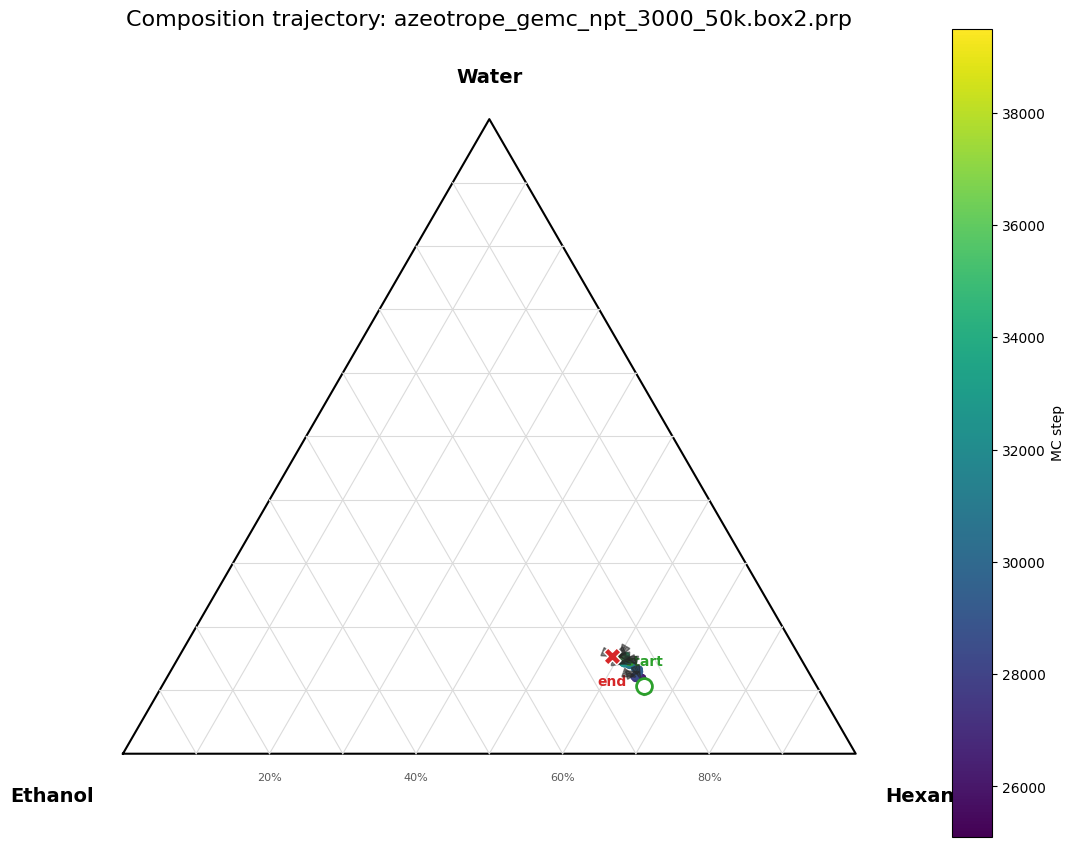

In [243]:
fig, ax = plot_ternary_trajectory(df)

output_png = INPUT_PRP.with_suffix(".ternary.png")
fig.savefig(output_png, dpi=220, bbox_inches="tight")
print(f"Saved: {output_png}")
plt.show()

## 5.1. Область с гексаном не менее 40%

Эта ячейка строит отдельный фрагмент тернарной диаграммы, ограниченный областью `x_hexane >= 0.40`. На траектории остаются начальная и конечная точки, а направляющая строится по сглаженным промежуточным составам. Линия `Гексан = 40%` служит границей и ориентиром.

Saved: /Users/artemis/Documents/S26S-all/Project-Labs-S26S/MC/azeotrop_data_2/azeotrope_gemc_npt_3000_50k.box2.ternary_hexane_ge_40.png


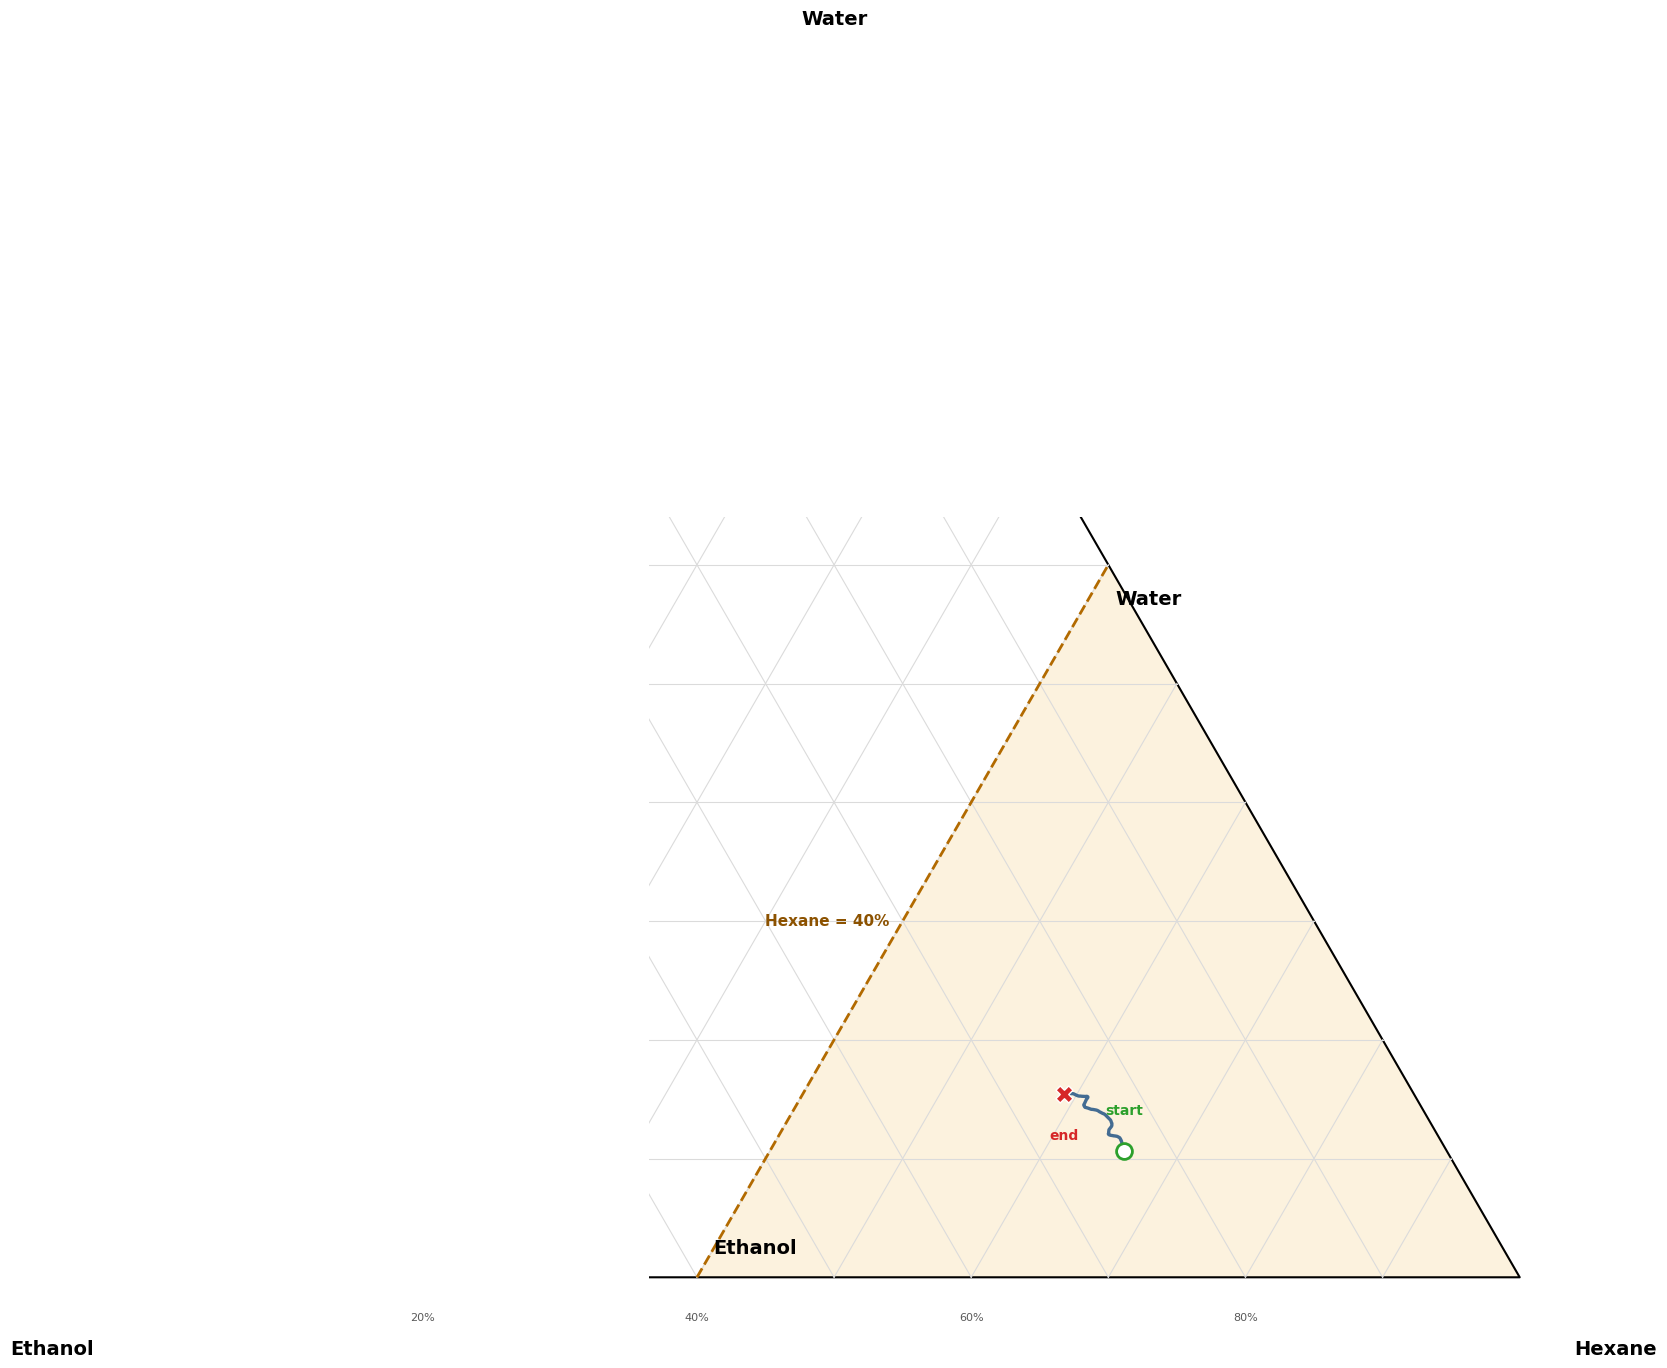

In [249]:
HEXANE_REGION_MIN = 0.40
HEXANE_REGION_MARGIN = 0.035
HEXANE_GUIDE_WINDOW = min(31, max(5, len(df) // 10))

hexane_region = np.array([
    [0.0, 0.0, 1.0],
    [0.0, 1.0 - HEXANE_REGION_MIN, HEXANE_REGION_MIN],
    [1.0 - HEXANE_REGION_MIN, 0.0, HEXANE_REGION_MIN],
])
hexane_boundary = hexane_region[1:]
region_x, region_y = ternary_to_xy(hexane_region)
boundary_x, boundary_y = ternary_to_xy(hexane_boundary)

fig, ax = plot_ternary_trajectory(
    df,
    show_points=False,
    show_arrows=False,
    show_colorbar=False,
    guide_smooth_window=HEXANE_GUIDE_WINDOW,
    title="",
)
ax.fill(region_x, region_y, color="#f2b84b", alpha=0.18, zorder=1)
ax.plot(
    boundary_x,
    boundary_y,
    color="#b26a00",
    lw=2.0,
    ls="--",
    zorder=5,
)
ax.text(
    boundary_x.mean() - 0.01,
    boundary_y.mean(),
    "Hexane = 40%",
    color="#8c5200",
    ha="right",
    va="center",
    fontsize=11,
    weight="bold",
    zorder=6,
)
ax.text(
    region_x[2] + 0.005,
    region_y[2] - 0.018,
    "Water",
    ha="left",
    va="top",
    fontsize=14,
    weight="bold",
    zorder=6,
)
ax.text(
    region_x[1] + 0.012,
    region_y[1] + 0.015,
    "Ethanol",
    ha="left",
    va="bottom",
    fontsize=14,
    weight="bold",
    zorder=6,
)
ax.set_xlim(region_x.min() - HEXANE_REGION_MARGIN, region_x.max() + HEXANE_REGION_MARGIN)
ax.set_ylim(region_y.min() - HEXANE_REGION_MARGIN, region_y.max() + HEXANE_REGION_MARGIN)

hexane_region_png = INPUT_PRP.with_suffix(".ternary_hexane_ge_40.png")
fig.savefig(hexane_region_png, dpi=220, bbox_inches="tight")
print(f"Saved: {hexane_region_png}")
plt.show()

## 5.2. Azeotrope reference points

This separate ternary plot compares the literature/model azeotrope points with the Monte Carlo `end` point. The experimental median is given as mass fractions `w` and converted to mole fractions with `$x_i = (w_i / M_i) / \sum_j (w_j / M_j)$` before plotting.

Saved: /Users/artemis/Documents/S26S-all/Project-Labs-S26S/MC/azeotrop_data_2/azeotrope_gemc_npt_3000_50k.box2.ternary_azeotrope_points.png


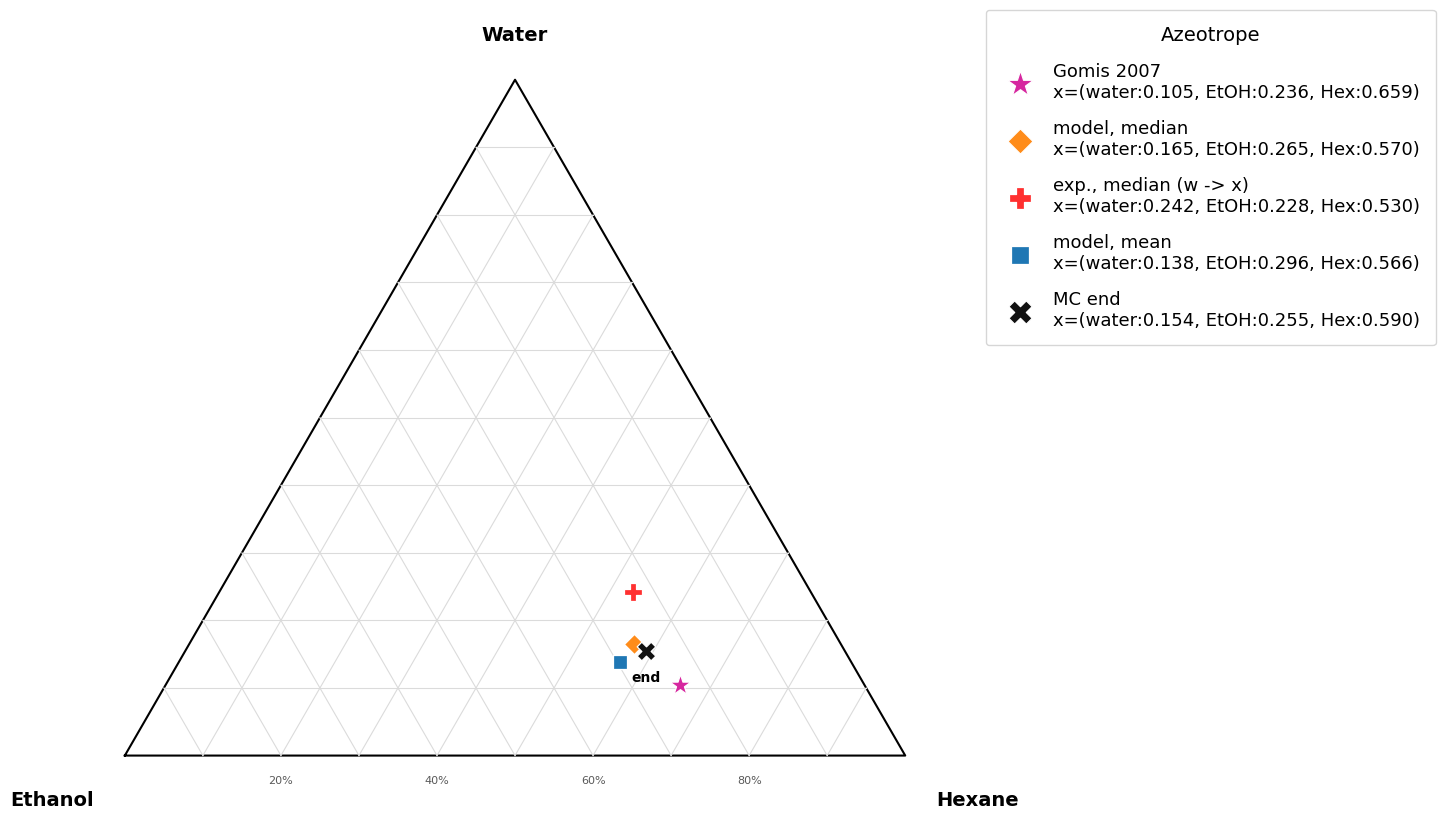

In [245]:
MOLAR_MASSES_G_MOL = np.array([18.01528, 46.06844, 86.178])


def normalize_fractions(fractions: np.ndarray) -> np.ndarray:
    fractions = np.asarray(fractions, dtype=float)
    return fractions / fractions.sum()


def mass_to_mole_fractions(mass_fractions: np.ndarray, molar_masses: np.ndarray) -> np.ndarray:
    mole_amounts = np.asarray(mass_fractions, dtype=float) / np.asarray(molar_masses, dtype=float)
    return normalize_fractions(mole_amounts)


def format_ternary_label(name: str, fractions: np.ndarray) -> str:
    water, ethanol, hexane = fractions
    return f"{name}\nx=(water:{water:.3f}, EtOH:{ethanol:.3f}, Hex:{hexane:.3f})"


exp_median_w = np.array([0.072, 0.174, 0.755])
exp_median_x = mass_to_mole_fractions(exp_median_w, MOLAR_MASSES_G_MOL)
mc_end_x = normalize_fractions(df[["x1", "x2", "x3"]].iloc[-1].to_numpy())

azeotrope_points = [
    {
        "name": "Gomis 2007",
        "fractions": normalize_fractions([0.105, 0.236, 0.658]),
        "marker": "*",
        "color": "#d6279f",
        "size": 250,
    },
    {
        "name": "model, median",
        "fractions": normalize_fractions([0.165, 0.265, 0.571]),
        "marker": "D",
        "color": "#ff8c1a",
        "size": 105,
    },
    {
        "name": "exp., median (w -> x)",
        "fractions": exp_median_x,
        "marker": "P",
        "color": "#ff3030",
        "size": 150,
    },
    {
        "name": "model, mean",
        "fractions": normalize_fractions([0.138, 0.296, 0.566]),
        "marker": "s",
        "color": "#1f77b4",
        "size": 110,
    },
    {
        "name": "MC end",
        "fractions": mc_end_x,
        "marker": "X",
        "color": "#111111",
        "size": 180,
    },
]

fig, ax = plt.subplots(figsize=(12, 10.5))
draw_ternary_axes(ax)

for point in azeotrope_points:
    point_x, point_y = ternary_to_xy(point["fractions"])
    ax.scatter(
        point_x,
        point_y,
        s=point["size"],
        marker=point["marker"],
        color=point["color"],
        edgecolor="white",
        linewidth=0.9,
        zorder=4,
        label=format_ternary_label(point["name"], point["fractions"]),
    )
    if point["name"] == "MC end":
        ax.text(point_x, point_y - 0.025, "end", ha="center", va="top", weight="bold", zorder=5)

ax.legend(
    title="Azeotrope",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    fontsize=13,
    title_fontsize=14,
    markerscale=1.25,
    labelspacing=1.0,
    borderpad=0.9,
)

azeotrope_points_png = INPUT_PRP.with_suffix(".ternary_azeotrope_points.png")
fig.savefig(azeotrope_points_png, dpi=220, bbox_inches="tight")
print(f"Saved: {azeotrope_points_png}")

azeotrope_points_table = pd.DataFrame(
    {
        "point": [point["name"] for point in azeotrope_points],
        "Water x": [point["fractions"][0] for point in azeotrope_points],
        "Ethanol x": [point["fractions"][1] for point in azeotrope_points],
        "Hexane x": [point["fractions"][2] for point in azeotrope_points],
    }
)
azeotrope_points_table.round(4)
plt.show()

## 6. Проверка выхода состава на плато

Плато `x0` оценивается средним по последним точкам траектории. Верхняя панель показывает сами мольные доли и уровни `x0`, а нижняя сводит все компоненты к одному критерию: остаток `x - x0` должен колебаться около нуля.

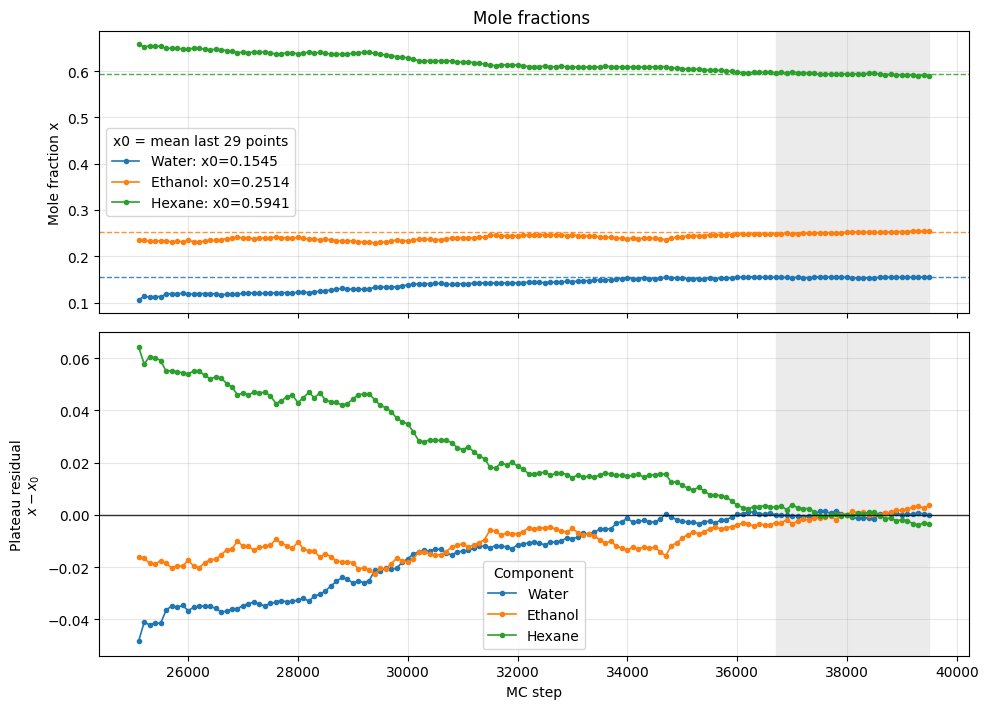

In [246]:
fraction_cols = ["x1", "x2", "x3"]
tail_count = max(1, int(len(df) * TAIL_FRACTION))
tail = df.tail(tail_count)
plateau = tail[fraction_cols].mean()
plateau_start = tail["step"].iloc[0]

fig, (ax_comp, ax_residual) = plt.subplots(
    2,
    1,
    figsize=(10, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.15]},
)

for col, label in zip(fraction_cols, COMPONENTS):
    line = ax_comp.plot(
        df["step"],
        df[col],
        marker="o",
        ms=3,
        lw=1.2,
        label=f"{label}: x0={plateau[col]:.4f}",
    )[0]
    color = line.get_color()
    ax_comp.axhline(plateau[col], color=color, ls="--", lw=1.0, alpha=0.85)
    ax_residual.plot(
        df["step"],
        df[col] - plateau[col],
        color=color,
        marker="o",
        ms=3,
        lw=1.2,
        label=label,
    )

for ax in (ax_comp, ax_residual):
    ax.axvspan(plateau_start, df["step"].iloc[-1], color="0.92", zorder=0)
    ax.grid(True, alpha=0.3)

ax_comp.set_ylabel("Mole fraction x")
ax_comp.set_title(f"Mole fractions ")
ax_comp.legend(title=f"x0 = mean last {tail_count} points")

ax_residual.axhline(0.0, color="black", lw=1.0, alpha=0.8)
ax_residual.set_xlabel("MC step")
ax_residual.set_ylabel("Plateau residual\n$x - x_0$")
ax_residual.legend(title="Component")

fig.tight_layout()
plt.show()

## 7. Релаксация pre-swap для `box2`

В текущем `.prp` Cassandra нет столбца температуры: этот файл записывает `Energy_Total`, `Pressure`, `Volume`, плотности и `Nmols`. Для данного NPT Monte Carlo запуска температура задаётся во входном файле через `Temperature_Info`, поэтому по этому `.prp` ниже строится доступный график релаксации энергии. Он показывает, как система снимает начальное неравновесие в pre-swap стадии. Следующая ячейка строит ту же энергию с логарифмической шкалой по вертикали.

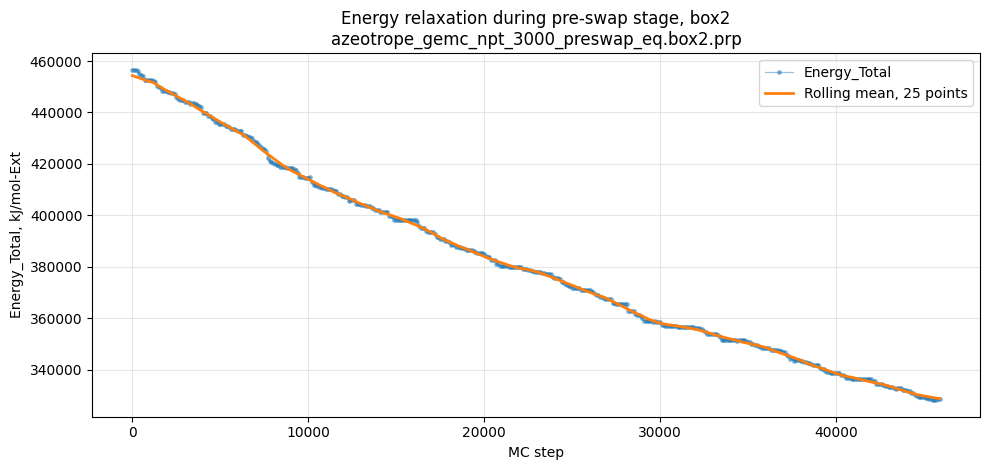

In [247]:
RELAXATION_PRP = (
    PROJECT_ROOT
    / "MC"
    / "azeotrop_data"
    / "azeotrope_gemc_npt_3000_preswap_eq.box2.prp"
)

relax_df = read_cassandra_prp(RELAXATION_PRP)
smooth_window = max(3, min(25, len(relax_df) // 10))
energy_smooth = relax_df["energy_total"].rolling(
    smooth_window,
    center=True,
    min_periods=1,
).mean()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    relax_df["step"],
    relax_df["energy_total"],
    marker="o",
    ms=2.5,
    lw=0.9,
    alpha=0.45,
    label="Energy_Total",
)
ax.plot(
    relax_df["step"],
    energy_smooth,
    lw=2.0,
    label=f"Rolling mean, {smooth_window} points",
)

ax.set_xlabel("MC step")
ax.set_ylabel("Energy_Total, kJ/mol-Ext")
ax.set_title(
    "Energy relaxation during pre-swap stage, box2\n"
    f"{RELAXATION_PRP.name}"
)
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()


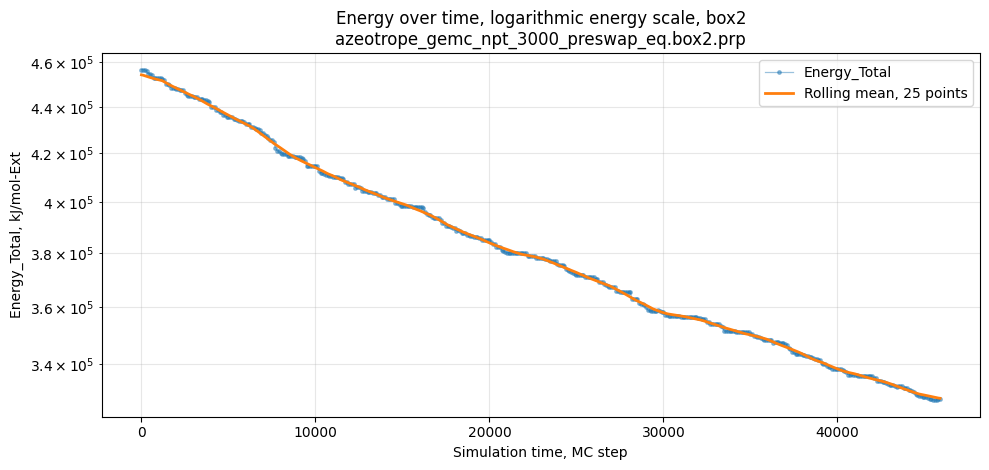

In [248]:
log_relax_df = relax_df[relax_df["energy_total"] > 0].copy()
log_energy_smooth = energy_smooth.loc[log_relax_df.index]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    log_relax_df["step"],
    log_relax_df["energy_total"],
    marker="o",
    ms=2.5,
    lw=0.9,
    alpha=0.45,
    label="Energy_Total",
)
ax.plot(
    log_relax_df["step"],
    log_energy_smooth,
    lw=2.0,
    label=f"Rolling mean, {smooth_window} points",
)

ax.set_yscale("log")
ax.set_xlabel("Simulation time, MC step")
ax.set_ylabel("Energy_Total, kJ/mol-Ext")
ax.set_title(
    "Energy over time, logarithmic energy scale, box2\n"
    f"{RELAXATION_PRP.name}"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()